In [8]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
data = pd.read_csv('AirPassengers_scaled.csv')
data['x'] = range(1, len(data) + 1)

In [12]:
x_train = np.array(data['x'].values)
y_train = np.array(data['Passengers_scaled'].values)

In [13]:
dev = qml.device("default.qubit", wires=1)

scaling = 1

def S(x):
    """ kodowanie danych 
    x - wartosc skalarna jednej zmiennej - do przewidywania szeregow czasowych 
    czyli najczęściej to bedzie reprezentować oś czasu.
    scaling - trochę nie wiem po co ale zakładam, ze pozwoli ustalić zakres od 0 do 2pi bo kąty się powtarzają
    """
    qml.RX(scaling * x, wires=0)

def W(theta):
    """
    trenowalny blok zalezacy od 3 katów 
    wymusza aby theta bylo przynajmniej listą (krotką) posiadającą 3 elementy
    minimalny model z zaladowaniem danych [[1.2,0.3,4.5],[1.2,0.3,4.5]] - musi zawierac przynajmniej dwie listy
    """
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev)
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])

    return qml.expval(qml.PauliZ(wires=0))

In [14]:
r = 4
weights = (np.random.random(size=(r+1, 3), requires_grad=True))

(<Figure size 1200x200 with 1 Axes>, <Axes: >)

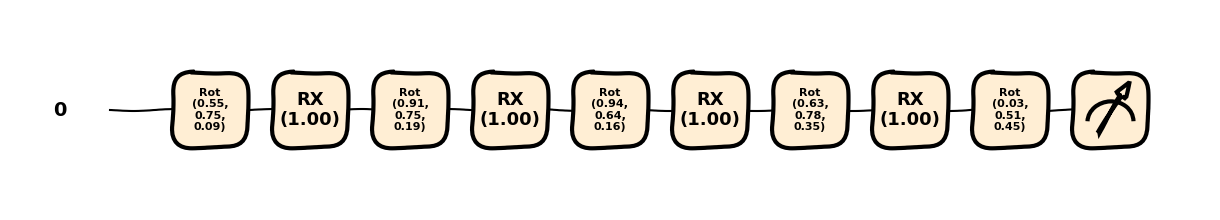

In [15]:
qml.draw_mpl(serial_quantum_model, decimals=2, level="device", style='sketch')(weights, 1.0)

In [16]:
# Koszt: MSE
def cost(weights, x_data, y_data):
    preds = np.array([serial_quantum_model(weights, x) for x in x_data])
    return np.mean((preds - y_data) ** 2)

r = 20
weights = (np.random.random(size=(r+1, 3), requires_grad=True))

# Optymalizacja
opt = qml.AdamOptimizer(stepsize=0.1)
epochs = 100

for epoch in range(epochs):
    weights = opt.step(lambda w: cost(w, x_train, y_train), weights)
    if epoch % 10 == 0:
        loss = cost(weights, x_train, y_train)
        print(f"Epoch {epoch}: loss = {loss:.6f}")

Epoch 0: loss = 0.480869
Epoch 10: loss = 0.366531
Epoch 20: loss = 0.252855
Epoch 30: loss = 0.222518
Epoch 40: loss = 0.216489
Epoch 50: loss = 0.213269
Epoch 60: loss = 0.212033
Epoch 70: loss = 0.211497
Epoch 80: loss = 0.211121
Epoch 90: loss = 0.210790


In [18]:
preds = np.array([serial_quantum_model(weights, x) for x in x_train])

In [27]:
def r2_score_np(y_true, y_pred):
    """Oblicza współczynnik determinacji R² dla numpy arrays"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2

def mae_np(y_true, y_pred):
    """Mean Absolute Error dla numpy arrays"""
    return np.mean(np.abs(y_true - y_pred))

def rmse_np(y_true, y_pred):
    """Root Mean Squared Error dla numpy arrays"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def smape_np(y_true, y_pred, eps=1e-8):
    """Symmetric Mean Absolute Percentage Error dla numpy arrays"""
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100


In [23]:
y_true = y_train
y_pred = preds

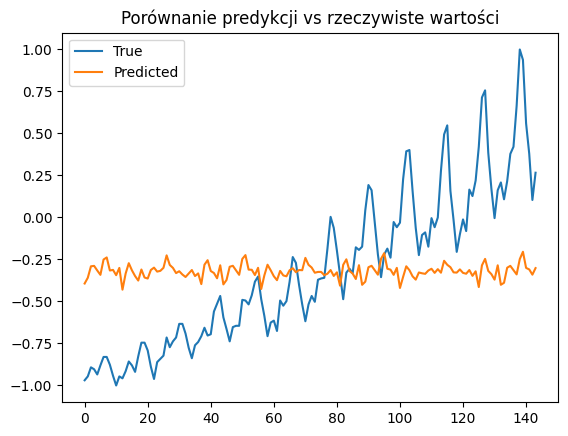

In [25]:
import matplotlib.pyplot as plt

plt.plot(y_true.numpy(), label='True')
plt.plot(y_pred.numpy(), label='Predicted')
plt.legend()
plt.title('Porównanie predykcji vs rzeczywiste wartości')
plt.show()

In [32]:
print(f"R²  ={r2_score_np(y_true, y_pred)}\nMSE  ={cost(weights,x_train, y_train)}" )
print(f"mae  ={mae_np(y_true, y_pred)}\nRMSE ={rmse_np(y_true, y_pred)}" )
print(f"smape ={smape_np(y_true, y_pred)}")

R²  =0.012173998448959611
MSE  =0.2104617234423344
mae  =0.3893491963628194
RMSE =0.4587610744628781
smape =104.04512448849353
